# Named Entity Recognition — Dataset Exploration

This notebook introduces the **CoNLL-2003** dataset and the IOB tagging scheme used for sequence labeling.

We will:
- load the open-source dataset,
- inspect its structure,
- map the dataset labels,
- look at token-level IOB tags,
- create a small training representation for spaCy.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

dataset = load_dataset(
    "lhoestq/conll2003",
    trust_remote_code=True
)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'lhoestq/conll2003' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


dataset_infos.json:   0%|          | 0.00/3.67k [00:00<?, ?B/s]

c:\Users\user\Desktop\Named-Entity-Recognition-NER\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\datasets--lhoestq--conll2003. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.07MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  259kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [15]:
label_names = [label_map[i] for i in sorted(label_map)]
label_names

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

In [16]:
label_map = {
    0: "O",
    1: "B-PER",
    2: "I-PER",
    3: "B-ORG",
    4: "I-ORG",
    5: "B-LOC",
    6: "I-LOC",
    7: "B-MISC",
    8: "I-MISC",
}

# The exact label ids are printed above, so the mapping is kept explicit
# for the standard CoNLL-2003 feature ordering.
label_map

{0: 'O',
 1: 'B-PER',
 2: 'I-PER',
 3: 'B-ORG',
 4: 'I-ORG',
 5: 'B-LOC',
 6: 'I-LOC',
 7: 'B-MISC',
 8: 'I-MISC'}

In [17]:
sample = dataset["train"][0]

rows = []
for token, tag_id in zip(sample["tokens"], sample["ner_tags"]):
    rows.append({
        "token": token,
        "tag_id": tag_id,
        "iob_tag": label_map[tag_id]
    })

pd.DataFrame(rows)

,token,tag_id,iob_tag
0,EU,3,B-ORG
1,rejects,0,O
2,German,7,B-MISC
3,call,0,O
4,to,0,O
5,boycott,0,O
6,British,7,B-MISC
7,lamb,0,O
8,.,0,O


## Understanding IOB Tags

**I**OB means **Inside–Outside–Beginning**.

- `B-PER`: beginning of a person entity
- `I-PER`: continuation of a person entity
- `B-ORG`: beginning of an organization entity
- `I-ORG`: continuation of an organization entity
- `B-LOC`: beginning of a location entity
- `I-LOC`: continuation of a location entity
- `O`: token is outside an entity

Example:

`Barack  Obama  visited  London`

`B-PER   I-PER   O        B-LOC`

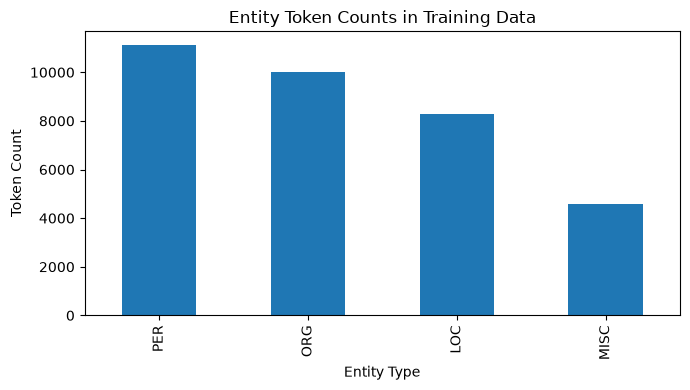

In [18]:
# Count the three entity groups used in this project.
from collections import Counter

tag_counts = Counter()
for row in dataset["train"]:
    for tag_id in row["ner_tags"]:
        tag = label_map[tag_id]
        if tag != "O":
            tag_counts[tag.split("-", 1)[1]] += 1

pd.Series(tag_counts).sort_values(ascending=False).plot(kind="bar", figsize=(7, 4))
plt.title("Entity Token Counts in Training Data")
plt.xlabel("Entity Type")
plt.ylabel("Token Count")
plt.tight_layout()
plt.show()

In [19]:
print("Train sentences:", len(dataset["train"]))
print("Validation sentences:", len(dataset["validation"]))
print("Test sentences:", len(dataset["test"]))
print("Entity labels used:", ["PER", "LOC", "ORG"])

Train sentences: 14041
Validation sentences: 3250
Test sentences: 3453
Entity labels used: ['PER', 'LOC', 'ORG']


### Next Step

In the next notebook, the IOB annotations will be converted into character spans and used to train a spaCy NER component.